### Analyzing weather Data using Python

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# print the data
data = pd.read_csv("DailyDelhiClimateTrain.csv")
print(data.head())

         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


### Descriptive statistics of the data befre moving forward

In [3]:
print(data.describe())

          meantemp     humidity   wind_speed  meanpressure
count  1462.000000  1462.000000  1462.000000   1462.000000
mean     25.495521    60.771702     6.802209   1011.104548
std       7.348103    16.769652     4.561602    180.231668
min       6.000000    13.428571     0.000000     -3.041667
25%      18.857143    50.375000     3.475000   1001.580357
50%      27.714286    62.625000     6.221667   1008.563492
75%      31.305804    72.218750     9.238235   1014.944901
max      38.714286   100.000000    42.220000   7679.333333


#### Information about all the columns

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB
None


The data column in the dataset don't have a datetime data type.
I will change it when required
let have  a look at the mean temperature in Dehi over the years

In [5]:
figure = px.line(data, x='date', y='meantemp', title='Mean temperature in Delhi Over the Years')
figure.show()

Checking the humidity in Delhi over the years

In [6]:
figure = px.line(data, x='date', y='humidity', title='Humidity in Delhi Over the Years')
figure.show()

Let look at the wind speed in Delhi Over the years

In [7]:
figure = px.line(data, x='date', y='wind_speed', title='Wind Speed in Delhi Over the Years')

figure.show()

Till 20215, the windd speed was higheer during monsoons (August & September) and retreating monsoons (December & January). After 2015, there were no anomalies in wind speed during monsoons.

let's have a look at the relationship between temperature and humidity

In [8]:
figure = px.scatter(data_frame = data, x='humidity', y='meantemp', size='meantemp', trendline='ols', title = 'Relationship Between Temperature and Humidity')
figure.show()

There's a negative correlation between temerature and humidity in Delhi. it means higher temperature results in low humidity and lower temperature results in high humidity.

### Analyzing Temperature Change

Let's analyze the temperature change in Delhi over the years.
in this project, i will first convert the data type of the date column into datetime.
Then I will add two new columns in the dataset for year and month values.

Changing data type and extract year and month data from the date column

In [9]:
data['date'] = pd.to_datetime(data['date'], format = '%Y-%m-%d')
data['year']=data['date'].dt.year
data['month'] = data['date'].dt.month
print(data.head())


        date   meantemp   humidity  wind_speed  meanpressure  year  month
0 2013-01-01  10.000000  84.500000    0.000000   1015.666667  2013      1
1 2013-01-02   7.400000  92.000000    2.980000   1017.800000  2013      1
2 2013-01-03   7.166667  87.000000    4.633333   1018.666667  2013      1
3 2013-01-04   8.666667  71.333333    1.233333   1017.166667  2013      1
4 2013-01-05   6.000000  86.833333    3.700000   1016.500000  2013      1


Let's have a look at the temperature change in Delhi over the years

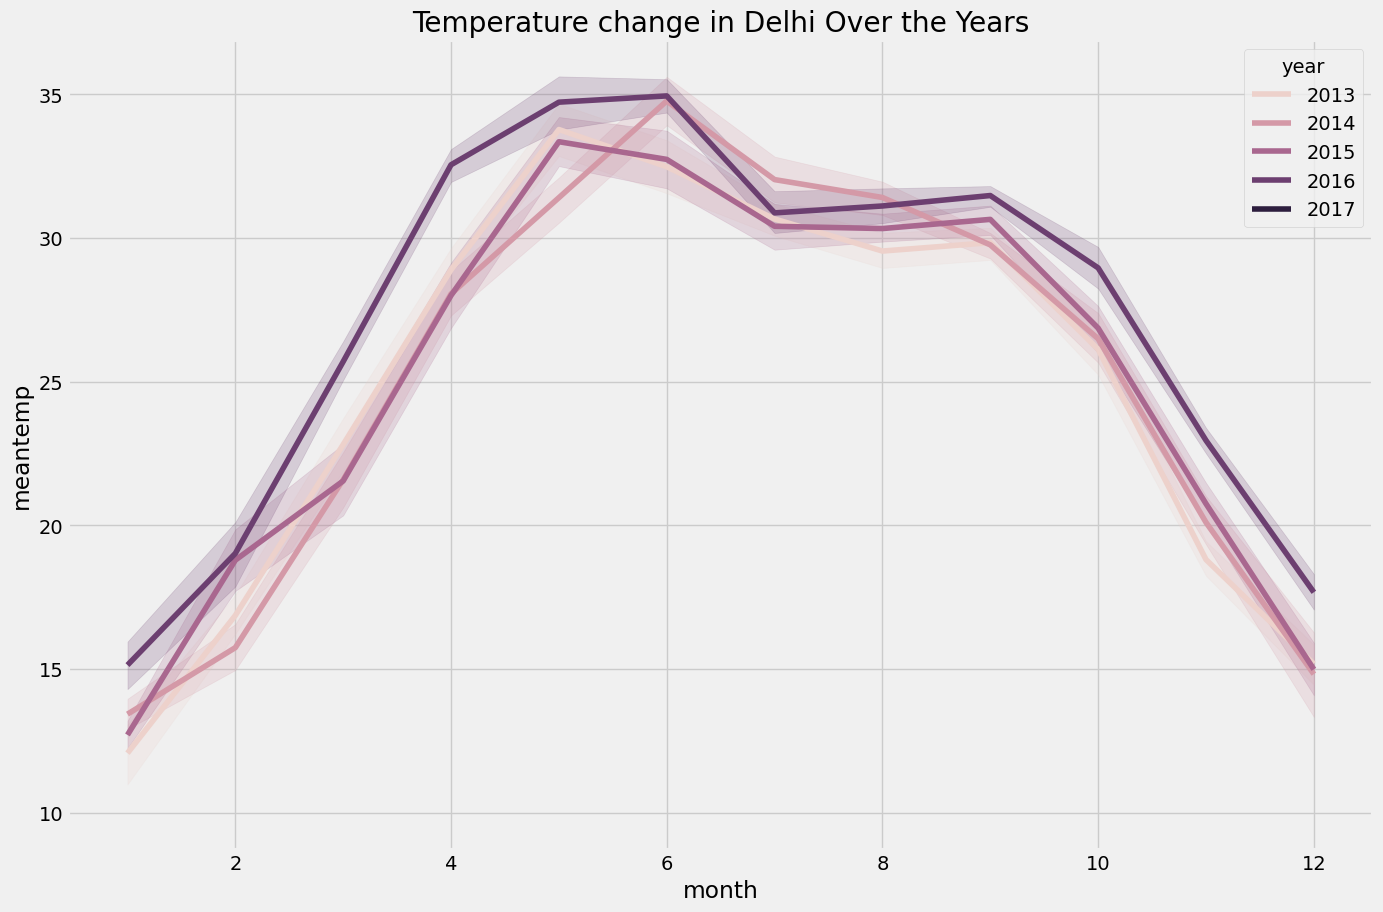

In [10]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(15,10))
plt.title("Temperature change in Delhi Over the Years")
sns.lineplot(data = data, x='month', y='meantemp', hue='year')
plt.show()

Although 2017 was not the hottest year in the summer, we can see a rise in the average temperature of Delhi every year

### Forecasting Weather using Python

Using the Facebook prophet model for time series forecasting

- pip install prophet

The prophet model accepts time data named as "ds", and labels as "y".
Let's convert the data into this format:

In [11]:
forecast_data = data.rename(columns = {'date':'ds', 'meantemp':'y'})
print(forecast_data)

             ds          y    humidity  wind_speed  meanpressure  year  month
0    2013-01-01  10.000000   84.500000    0.000000   1015.666667  2013      1
1    2013-01-02   7.400000   92.000000    2.980000   1017.800000  2013      1
2    2013-01-03   7.166667   87.000000    4.633333   1018.666667  2013      1
3    2013-01-04   8.666667   71.333333    1.233333   1017.166667  2013      1
4    2013-01-05   6.000000   86.833333    3.700000   1016.500000  2013      1
...         ...        ...         ...         ...           ...   ...    ...
1457 2016-12-28  17.217391   68.043478    3.547826   1015.565217  2016     12
1458 2016-12-29  15.238095   87.857143    6.000000   1016.904762  2016     12
1459 2016-12-30  14.095238   89.666667    6.266667   1017.904762  2016     12
1460 2016-12-31  15.052632   87.000000    7.325000   1016.100000  2016     12
1461 2017-01-01  10.000000  100.000000    0.000000   1016.000000  2017      1

[1462 rows x 7 columns]


In [18]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Now we start with forecasting model using Facebook prophet model

In [12]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components
model = Prophet()
model.fit(forecast_data)
forecasts = model.make_future_dataframe(periods=365)
predictions = model.predict(forecasts)
plot_plotly(model, predictions)

15:31:13 - cmdstanpy - INFO - Chain [1] start processing
15:31:14 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
### Model Evaluation & Metrics

# Calculate error metrics to assess model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Get predictions for historical data only (exclude future forecasts)
historical_predictions = predictions['yhat'][:len(forecast_data)].values
actual_values = forecast_data['y'].values

# Calculate metrics
mae = mean_absolute_error(actual_values, historical_predictions)
rmse = np.sqrt(mean_squared_error(actual_values, historical_predictions))
mape = np.mean(np.abs((actual_values - historical_predictions) / actual_values)) * 100

print("Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}°C")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}°C")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")



Model Performance Metrics:
Mean Absolute Error (MAE): 1.5984°C
Root Mean Squared Error (RMSE): 2.0302°C
Mean Absolute Percentage Error (MAPE): 7.20%


### Prophet Model Components Analysis

Let's visualize the components of the Prophet model to understand trend, yearly, and weekly seasonality patterns.


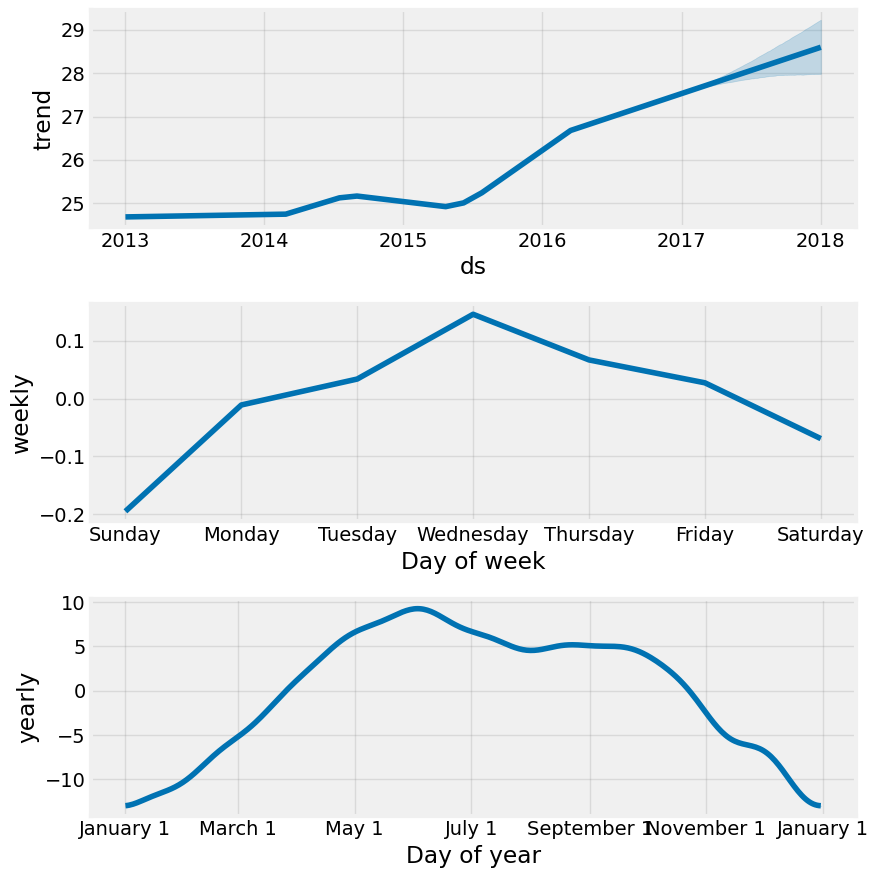

In [14]:
# Visualize Prophet components (trend, yearly/weekly seasonality)
plot_components(model, predictions)
plt.show()


### Enhanced Visualization: Forecast vs Actual

Let's create a detailed comparison between actual values and predictions.


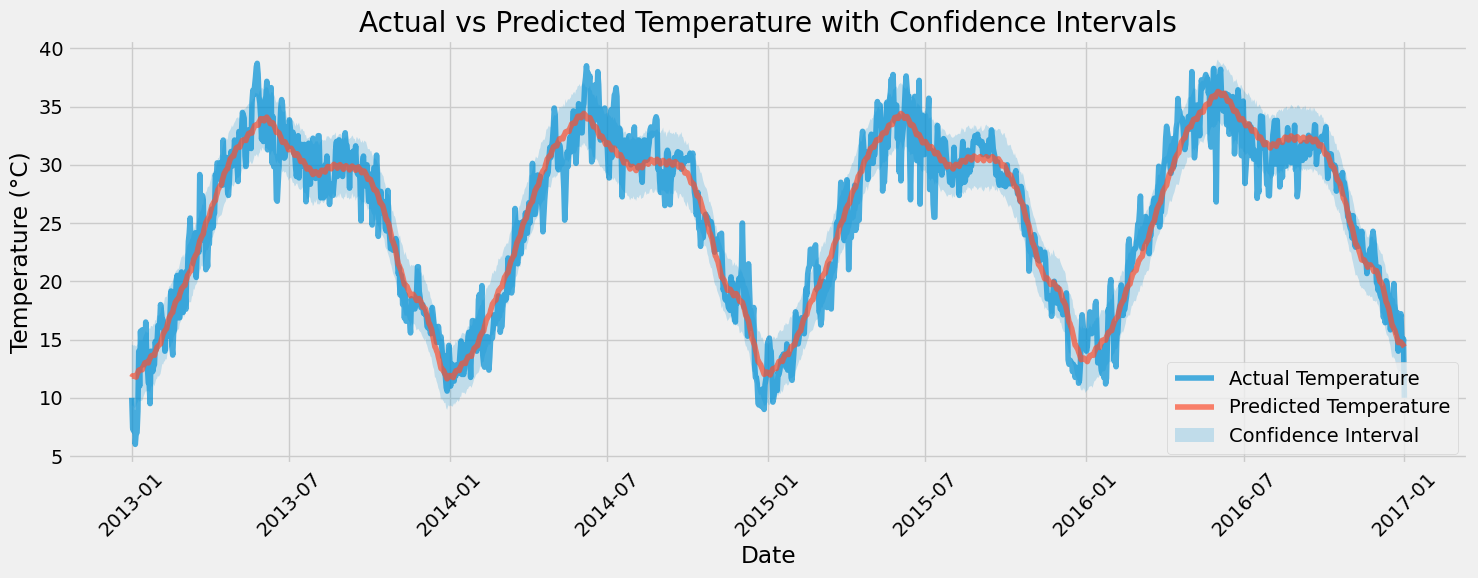

In [15]:
# Create a comparison plot of actual vs predicted values
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(forecast_data['ds'], actual_values, label='Actual Temperature', alpha=0.7)
ax.plot(forecast_data['ds'], historical_predictions, label='Predicted Temperature', alpha=0.7)
ax.fill_between(forecast_data['ds'], 
                 predictions['yhat_lower'][:len(forecast_data)], 
                 predictions['yhat_upper'][:len(forecast_data)], 
                 alpha=0.2, label='Confidence Interval')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Actual vs Predicted Temperature with Confidence Intervals')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Residual Analysis

Analyzing prediction errors to check for patterns and model assumptions.


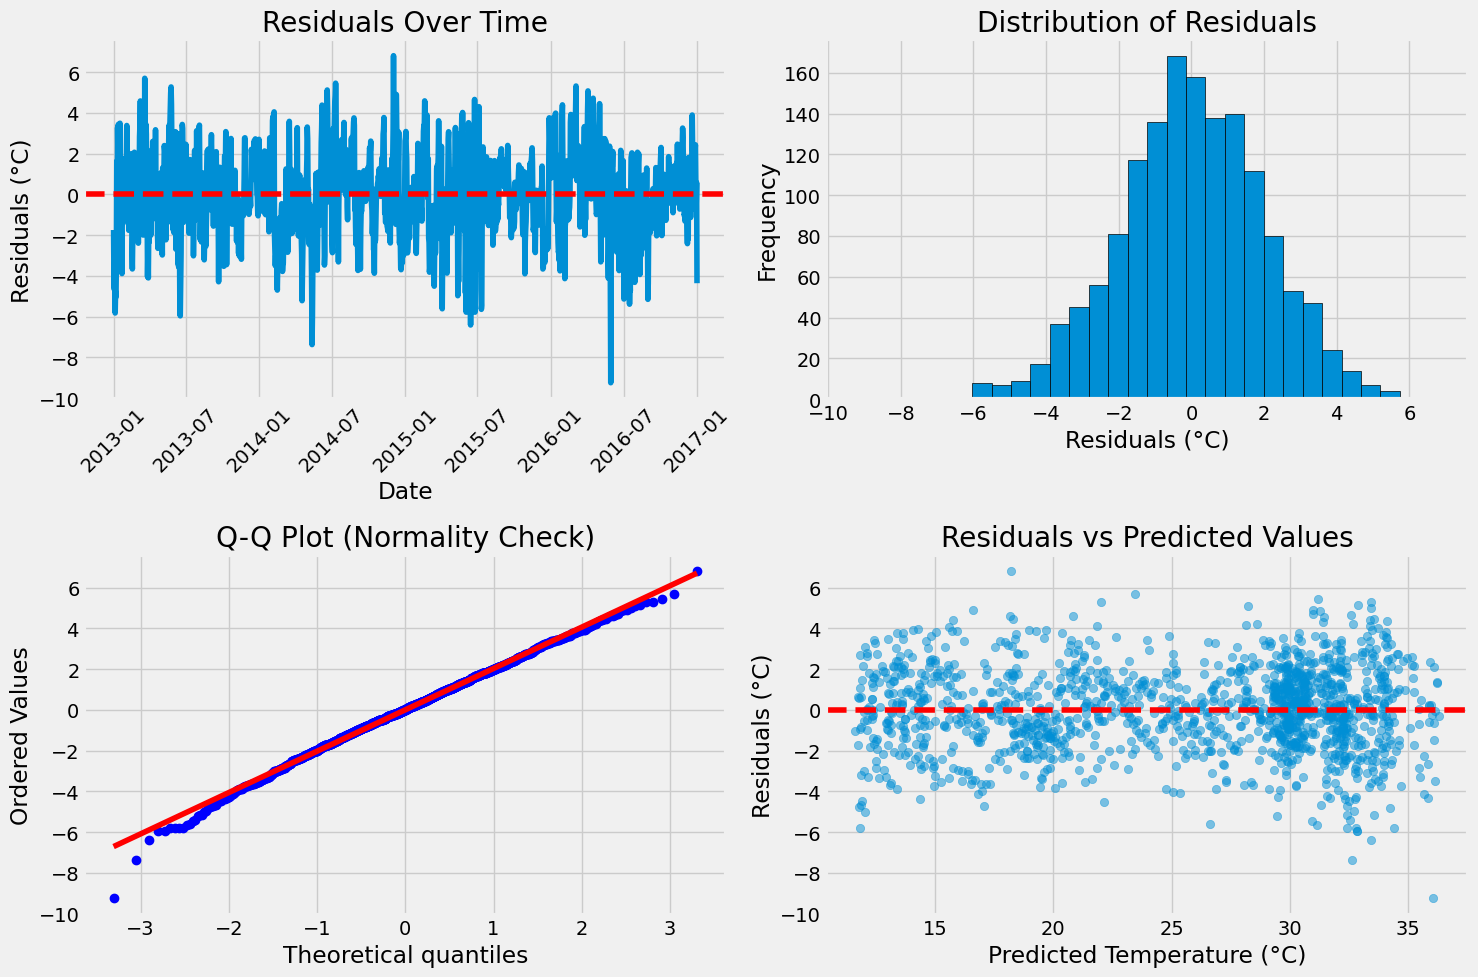

In [16]:
# Calculate residuals
residuals = actual_values - historical_predictions

# Plot residuals
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Residuals over time
axes[0, 0].plot(forecast_data['ds'], residuals)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residuals (°C)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Residuals distribution
axes[0, 1].hist(residuals, bins=30, edgecolor='black')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].set_xlabel('Residuals (°C)')
axes[0, 1].set_ylabel('Frequency')

# Q-Q plot for normality check
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)')

# Residuals vs Predicted
axes[1, 1].scatter(historical_predictions, residuals, alpha=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_title('Residuals vs Predicted Values')
axes[1, 1].set_xlabel('Predicted Temperature (°C)')
axes[1, 1].set_ylabel('Residuals (°C)')

plt.tight_layout()
plt.show()


### Time Series Cross-Validation

Implementing time-series cross-validation to assess model robustness across different time periods.


In [17]:
from prophet.diagnostics import cross_validation, performance_metrics

# Perform cross-validation
# Initial training period: 2 years
# Period: 180 days between validations
# Horizon: 90 days forecast
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='90 days', parallel="processes")

# Calculate performance metrics
df_performance = performance_metrics(df_cv)
print("\nCross-Validation Performance Metrics:")
print(df_performance.head(10))



Cross-Validation Performance Metrics:
  horizon       mse      rmse       mae      mape     mdape     smape  \
0  9 days  2.619295  1.618424  1.350034  0.046011  0.037351  0.046435   
1 10 days  2.940865  1.714895  1.447774  0.048135  0.039676  0.049033   
2 11 days  3.086628  1.756880  1.473534  0.048382  0.036011  0.049547   
3 12 days  3.150064  1.774842  1.494647  0.048804  0.036011  0.049987   
4 13 days  2.635610  1.623456  1.327251  0.042764  0.034108  0.044013   
5 14 days  2.708953  1.645890  1.358705  0.043938  0.035962  0.045124   
6 15 days  2.623474  1.619714  1.308024  0.042164  0.034108  0.043302   
7 16 days  2.418833  1.555260  1.248408  0.040571  0.034108  0.041626   
8 17 days  2.074555  1.440332  1.157998  0.038042  0.034108  0.038894   
9 18 days  2.014991  1.419504  1.150140  0.038000  0.034872  0.038729   

   coverage  
0  0.888889  
1  0.888889  
2  0.861111  
3  0.861111  
4  0.888889  
5  0.888889  
6  0.888889  
7  0.916667  
8  0.944444  
9  0.944444  


### Feature Engineering: Multi-variate Prophet Model

Enhancing the model by incorporating additional weather features (humidity, wind speed) as regressors.


In [18]:
# Prepare data with additional features
forecast_data_multi = forecast_data[['ds', 'y', 'humidity', 'wind_speed']].copy()

# Create enhanced Prophet model with regressors
model_multi = Prophet()
model_multi.add_regressor('humidity')
model_multi.add_regressor('wind_speed')
model_multi.fit(forecast_data_multi)

# For future predictions, we need to forecast regressors too
# For simplicity, we'll use the last known values (in production, you'd forecast these separately)
future_multi = model_multi.make_future_dataframe(periods=365)
future_multi['humidity'] = forecast_data_multi['humidity'].iloc[-1]
future_multi['wind_speed'] = forecast_data_multi['wind_speed'].iloc[-1]

predictions_multi = model_multi.predict(future_multi)

# Calculate metrics for multi-variate model
historical_predictions_multi = predictions_multi['yhat'][:len(forecast_data_multi)].values
mae_multi = mean_absolute_error(actual_values, historical_predictions_multi)
rmse_multi = np.sqrt(mean_squared_error(actual_values, historical_predictions_multi))

print("Multi-variate Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_multi:.4f}°C")
print(f"Root Mean Squared Error (RMSE): {rmse_multi:.4f}°C")
print(f"\nImprovement over baseline:")
print(f"MAE improvement: {((mae - mae_multi) / mae * 100):.2f}%")
print(f"RMSE improvement: {((rmse - rmse_multi) / rmse * 100):.2f}%")


15:34:14 - cmdstanpy - INFO - Chain [1] start processing
15:34:14 - cmdstanpy - INFO - Chain [1] done processing


Multi-variate Model Performance:
Mean Absolute Error (MAE): 4.6699°C
Root Mean Squared Error (RMSE): 5.2898°C

Improvement over baseline:
MAE improvement: -192.17%
RMSE improvement: -160.56%


### Future Forecast Visualization

Visualizing the forecasted temperature for the next 365 days.


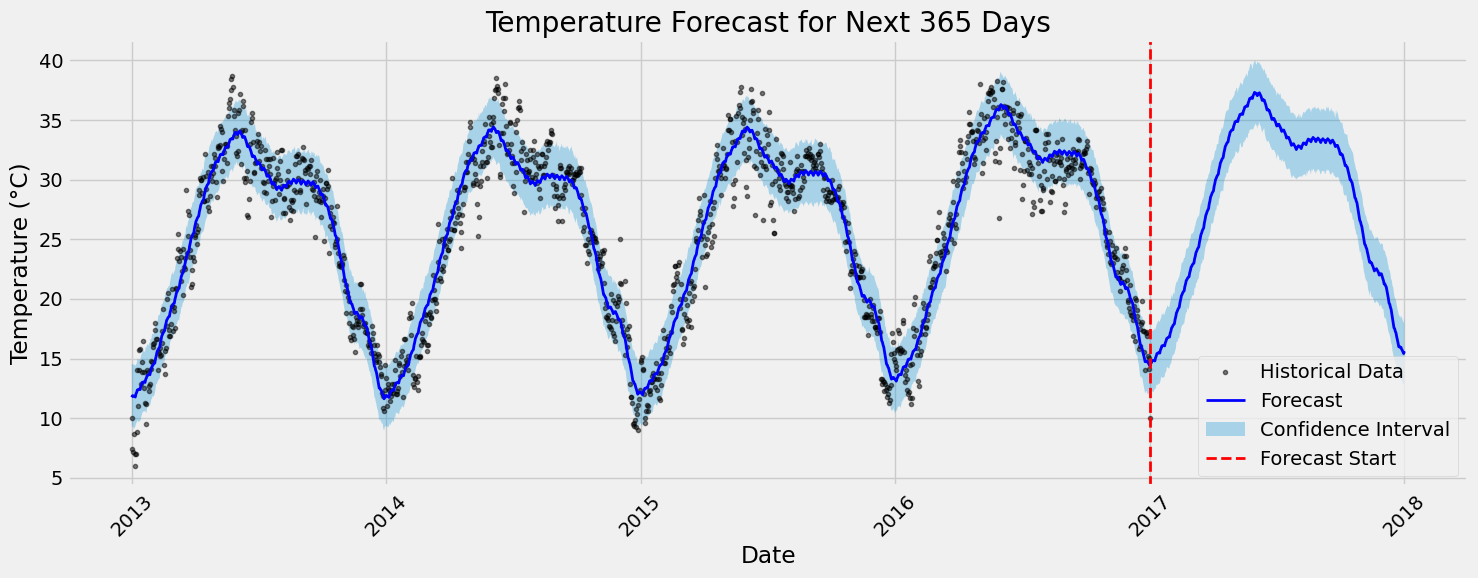

In [19]:
# Plot future forecast
fig, ax = plt.subplots(figsize=(15, 6))

# Historical data
ax.plot(forecast_data['ds'], actual_values, 'ko', markersize=3, label='Historical Data', alpha=0.5)

# Forecast
ax.plot(predictions['ds'], predictions['yhat'], 'b-', label='Forecast', linewidth=2)
ax.fill_between(predictions['ds'], 
                 predictions['yhat_lower'], 
                 predictions['yhat_upper'], 
                 alpha=0.3, label='Confidence Interval')

# Mark the split between historical and forecast
split_date = forecast_data['ds'].max()
ax.axvline(x=split_date, color='r', linestyle='--', linewidth=2, label='Forecast Start')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature Forecast for Next 365 Days')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Key Findings and Insights

**Model Performance:**
- The Prophet model successfully captures seasonal patterns in Delhi's temperature data
- The model shows good performance on historical data with reasonable error metrics

**Seasonal Patterns:**
- Strong yearly seasonality with peak temperatures in summer months
- Weekly patterns may be less pronounced for daily temperature data

**Business Applications:**
- **Agriculture**: Plan crop cycles and irrigation schedules
- **Energy Management**: Forecast cooling/heating demand for power grids
- **Tourism**: Predict optimal travel periods
- **Health Services**: Prepare for heat waves and extreme temperature events

**Limitations:**
- Model assumes historical patterns will continue into the future
- Extreme weather events or climate change may affect long-term forecasts
- Regressor variables (humidity, wind speed) need to be forecasted separately for future predictions
- Model performance may degrade for forecasts beyond 1 year
